In [3]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score

In [4]:
df = pd.read_csv("../data/environmental/flood.csv")

In [5]:
X = df.drop("FloodProbability", axis=1)

In [6]:
y = df["FloodProbability"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
print(X_train.shape)
print(X_test.shape)

(40000, 20)
(10000, 20)


In [9]:
model = LinearRegression()

In [10]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[0. ,0. ,0.01,...,0.01,0.01,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](20,)","['MonsoonIntensity','TopographyDrainage','RiverManagement',..., 'WetlandLoss','InadequatePlanning','PoliticalFactors']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.661e-16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)


In [11]:
predictions = model.predict(X_test)

In [12]:
mse = mean_squared_error(y_test, predictions)

print(mse)

1.1059860706077696e-31


In [13]:
r2 = r2_score(y_test, predictions)

print(r2)

1.0


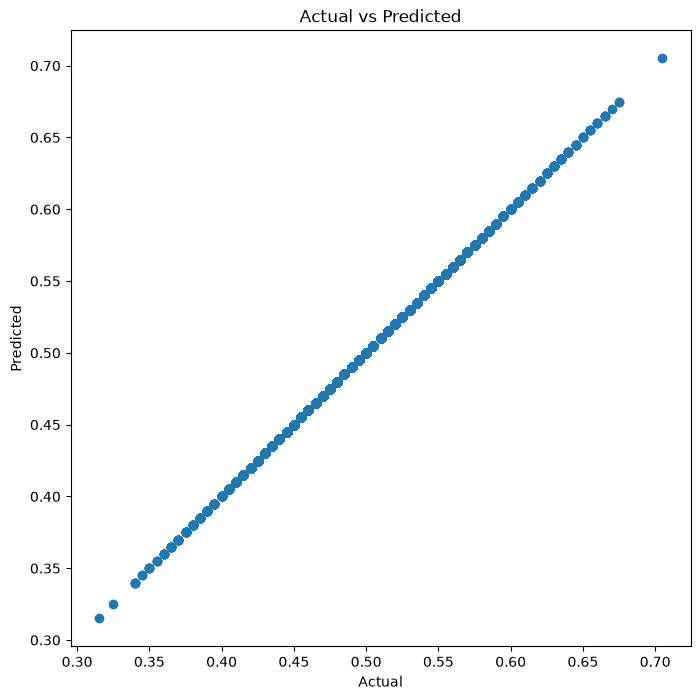

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(y_test, predictions)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [15]:
df.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='str')

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:")
print(model.coef_)

print("\nIntercept:")
print(model.intercept_)

Coefficients:
[0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005
 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005]

Intercept:
6.661338147750939e-16


In [17]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": model.predict(X_test)[:10]
})

comparison

,Actual,Predicted
0,0.455,0.455
1,0.495,0.495
2,0.470,0.470
3,0.460,0.460
4,0.465,0.465
5,0.535,0.535
6,0.490,0.490
7,0.480,0.480
8,0.605,0.605
9,0.490,0.490
